# 14 · Chemical reaction equilibrium

How much ammonia can a reactor make at 450 degC and 200 bar? Why is hydrogen made by steam reforming at
900 degC and methanol synthesised at 250 degC? Thermodynamics sets the ceiling on every reaction's conversion
before any catalyst is chosen. This notebook computes equilibrium constants from formation data, follows them
with temperature, and finds equilibrium compositions - for one reaction and for a whole reacting mixture.

**What you will learn**
- compute reaction enthalpies, Gibbs energies and equilibrium constants as functions of temperature
- find equilibrium conversions of single reactions and the effects of T, p and inerts
- solve multi-reaction equilibria by Gibbs minimisation
- connect equilibrium limits to process conditions

**Before you start:** notebooks 01 and 07  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import reaction
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## From formation data to the equilibrium constant
$\Delta G^\circ(T) = \Delta H^\circ(T) - T\Delta S^\circ(T)$, built from the enthalpies and Gibbs energies of formation at 25 degC and the
heat capacities; then $K = \exp(-\Delta G^\circ/RT)$:

ammonia synthesis: N2 + 3 H2 -> 2 NH3     : dH298 =   -92.2 kJ/mol, K(298) =  5.81e+05, K(1000 K) =  3.18e-07
methanol synthesis: CO + 2 H2 -> CH3OH    : dH298 =   -90.1 kJ/mol, K(298) =   2.2e+04, K(1000 K) =  2.79e-08
steam reforming: CH4 + H2O -> CO + 3 H2   : dH298 =   205.8 kJ/mol, K(298) =   1.4e-25, K(1000 K) =      26.9
water-gas shift: CO + H2O -> CO2 + H2     : dH298 =   -41.2 kJ/mol, K(298) =  1.03e+05, K(1000 K) =      1.42


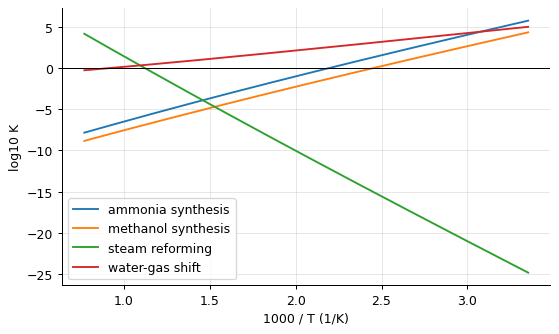

In [2]:
rxns = {"ammonia synthesis: N2 + 3 H2 -> 2 NH3": {"N2": -1, "H2": -3, "NH3": 2},
        "methanol synthesis: CO + 2 H2 -> CH3OH": {"CO": -1, "H2": -2, "methanol": 1},
        "steam reforming: CH4 + H2O -> CO + 3 H2": {"CH4": -1, "H2O": -1, "CO": 1, "H2": 3},
        "water-gas shift: CO + H2O -> CO2 + H2": {"CO": -1, "H2O": -1, "CO2": 1, "H2": 1}}
Ts = np.linspace(298.15, 1300, 200)
fig, ax = plt.subplots()
for name, rxn in rxns.items():
    ax.plot(1000 / Ts, [np.log10(reaction.equilibrium_constant(rxn, T)) for T in Ts], label=name.split(":")[0])
    print(f"{name:<42}: dH298 = {reaction.standard_enthalpy(rxn)/1e3:7.1f} kJ/mol, K(298) = {reaction.equilibrium_constant(rxn):9.3g}, K(1000 K) = {reaction.equilibrium_constant(rxn, 1000.0):9.3g}")
ax.axhline(0, color="k", lw=0.8); ax.set(xlabel="1000 / T (1/K)", ylabel="log10 K"); ax.legend(); plt.show()

The van 't Hoff plot: exothermic reactions (ammonia, methanol, shift) have $K$ falling with temperature -
they want low temperature but need high temperature for the catalyst to work, the central compromise of
their processes. Endothermic reforming goes the other way: only above about 900 K is $K$ large.

## The van 't Hoff approximation

In [3]:
rxn = rxns["ammonia synthesis: N2 + 3 H2 -> 2 NH3"]
for T in (500.0, 700.0, 900.0):
    print(f"{T:.0f} K: exact K = {reaction.equilibrium_constant(rxn, T):.3e}, van 't Hoff from 298 K with constant dH = {reaction.van_t_hoff(rxn, 298.15, T):.3e}")

500 K: exact K = 9.896e-02, van 't Hoff from 298 K with constant dH = 1.744e-01
700 K: exact K = 8.433e-05, van 't Hoff from 298 K with constant dH = 3.083e-04
900 K: exact K = 1.385e-06, van 't Hoff from 298 K with constant dH = 9.116e-06


Assuming a constant heat of reaction is adequate over a hundred kelvin, not over six hundred: the heat
capacities change $\Delta H^\circ$ enough to shift $K$ by a factor of two or more.

## Ammonia: the Haber-Bosch compromise
For a single reaction the equilibrium composition follows from $K = \prod(y_ip/p^\circ)^{\nu_i}$ and the reaction extent:

In [4]:
feed = {"N2": 1.0, "H2": 3.0}
rows = []
for T_C in (300, 400, 450, 500):
    for p_bar in (50, 100, 200, 300):
        ex = reaction.extent(rxn, feed, T_C + 273.15, p_bar * 1e5)
        rows.append((T_C, p_bar, ex["y"]["NH3"]))
t = pd.DataFrame(rows, columns=["T (degC)", "p (bar)", "y_NH3"]).pivot(index="T (degC)", columns="p (bar)", values="y_NH3")
print("equilibrium mole fraction of ammonia (stoichiometric feed, ideal gas):"); print(t.round(3))

equilibrium mole fraction of ammonia (stoichiometric feed, ideal gas):
p (bar)     50     100    200    300
T (degC)                            
300       0.395  0.513  0.621  0.677
400       0.153  0.244  0.356  0.425
450       0.092  0.158  0.250  0.314
500       0.056  0.101  0.172  0.226


Low temperature and high pressure favour ammonia, as Le Chatelier's principle says - the reaction is
exothermic and reduces the number of moles. But below about 400 degC the iron catalyst is too slow, so
industry runs at 400-500 degC and 150-300 bar, accepts 15-25 % conversion per pass, and recycles the rest.
(At 300 bar the gas is not ideal; fugacity coefficients, notebook 05, raise the equilibrium conversion somewhat.)

Inerts (argon, methane) that accumulate in the recycle dilute the reactants and lower the conversion:

In [5]:
for inert in (0.0, 0.5, 1.0):
    ex = reaction.extent(rxn, {"N2": 1.0, "H2": 3.0, "Ar": inert}, 723.15, 200e5)
    print(f"{inert:.1f} mol Ar per mol N2: y_NH3 = {ex['y']['NH3']:.3f}, extent {ex['extent']:.3f}")

0.0 mol Ar per mol N2: y_NH3 = 0.250, extent 0.400
0.5 mol Ar per mol N2: y_NH3 = 0.199, extent 0.373
1.0 mol Ar per mol N2: y_NH3 = 0.163, extent 0.350


## Hydrogen by steam reforming: many reactions at once
Reforming, water-gas shift and methanation happen together. Rather than juggling three coupled
equilibria, minimise the Gibbs energy of the whole mixture subject to the element balances:

In [6]:
species = ["CH4", "H2O", "CO", "CO2", "H2"]
rows = []
for T_C in (500, 600, 700, 800, 900, 1000):
    gm = reaction.gibbs_minimization(species, {"CH4": 1.0, "H2O": 3.0}, T_C + 273.15, 20e5)
    rows.append((T_C, *[gm["y"][s] for s in species], 1 - gm["moles"]["CH4"]))
print(pd.DataFrame(rows, columns=["T (degC)"] + [f"y {s}" for s in species] + ["CH4 conversion"]).round(3).to_string(index=False))

 T (degC)  y CH4  y H2O  y CO  y CO2  y H2  CH4 conversion
      500  0.199  0.633 0.001  0.032 0.133           0.144
      600  0.158  0.544 0.009  0.053 0.237           0.279
      700  0.104  0.443 0.033  0.065 0.356           0.482
      800  0.049  0.354 0.074  0.060 0.463           0.735
      900  0.013  0.307 0.109  0.049 0.522           0.921
     1000  0.003  0.298 0.125  0.040 0.535           0.984


At 20 bar and a steam-to-carbon ratio of 3, methane conversion needs about 900 degC - the reason reformer
tubes glow. The CO/CO$_2$ split is governed by the shift equilibrium and the hydrogen yield by both reactions
together. The reformate then passes shift reactors at lower temperature to convert CO into more H$_2$ and CO$_2$:

In [7]:
gm_ref = reaction.gibbs_minimization(species, {"CH4": 1.0, "H2O": 3.0}, 900 + 273.15, 20e5)
n = gm_ref["moles"]
shift = {"CO": -1, "H2O": -1, "CO2": 1, "H2": 1}
for T_C in (450, 350, 200):
    sh = reaction.extent(shift, n, T_C + 273.15, 20e5)                     # only the shift reaction proceeds on a shift catalyst
    print(f"shift reactor at {T_C} degC: H2 {sh['moles']['H2']:.3f} mol, CO {sh['moles']['CO']:.4f} mol, CO2 {sh['moles']['CO2']:.3f} mol per mol CH4 fed")
print(f"\noverall: about {sh['moles']['H2']:.2f} mol H2 and {sh['moles']['CO2'] + sh['moles']['CO']:.2f} mol CO2 per mol of methane - "
      f"{(sh['moles']['CO2'] + sh['moles']['CO']) * 44.01 / (sh['moles']['H2'] * 2.016):.1f} kg CO2 per kg H2 before any fuel is burnt for the reformer")
full = reaction.gibbs_minimization(species, n, 450 + 273.15, 20e5)
print(f"\nbut the FULL equilibrium of the same gas at 450 degC: CH4 {full['moles']['CH4']:.2f} mol, H2 {full['moles']['H2']:.2f} mol - methanation!")

shift reactor at 450 degC: H2 3.458 mol, CO 0.2276 mol, CO2 0.694 mol per mol CH4 fed
shift reactor at 350 degC: H2 3.577 mol, CO 0.1089 mol, CO2 0.812 mol per mol CH4 fed
shift reactor at 200 degC: H2 3.673 mol, CO 0.0121 mol, CO2 0.909 mol per mol CH4 fed

overall: about 3.67 mol H2 and 0.92 mol CO2 per mol of methane - 5.5 kg CO2 per kg H2 before any fuel is burnt for the reformer

but the FULL equilibrium of the same gas at 450 degC: CH4 0.90 mol, H2 0.39 mol - methanation!


Two lessons. First, the shift reactors recover most of the hydrogen bound in CO: about 3.7 mol H$_2$ per mol of
methane against the stoichiometric maximum of 4. Second - and easy to miss - the *complete* equilibrium of
the reformer gas at 450 degC is not shifted gas at all but methane: at that temperature and pressure,
methanation (CO + 3 H$_2$ -> CH$_4$ + H$_2$O) is thermodynamically overwhelming. Shift reactors work only because
their catalysts are selective. Thermodynamics tells you what *can* happen; the catalyst decides what *does*.

"Grey" hydrogen from natural gas thus carries about 5.5 kg of CO$_2$ per kg of hydrogen from the chemistry
alone and roughly 9-10 kg once the reformer's fuel is counted - the numbers that motivate carbon capture on
reformers ("blue" hydrogen) and electrolysis from renewable power ("green" hydrogen, notebook 16).

## Inside the algorithm: Delta G°(T) from formation data
$\Delta H^\circ(T) = \Delta H^\circ_{298} + \int C_p\,dT$, $\Delta S^\circ(T) = (\Delta H^\circ_{298} - \Delta G^\circ_{298})/298.15 + \int C_p/T\,dT$, then $\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$:

In [8]:
from engthermo import components, idealgas
T_ = 700.0
dH298 = sum(nu * components.get(s).Hf for s, nu in rxn.items()); dG298 = sum(nu * components.get(s).Gf for s, nu in rxn.items())
dH = dH298 + sum(nu * idealgas.enthalpy_change(s, 298.15, T_) for s, nu in rxn.items())
dS = (dH298 - dG298) / 298.15 + sum(nu * idealgas.entropy_change(s, 298.15, T_) for s, nu in rxn.items())
print(f"by hand: K(700 K) = {np.exp(-(dH - T_ * dS) / (R * T_)):.4e};  library: {reaction.equilibrium_constant(rxn, T_):.4e}")

by hand: K(700 K) = 8.4329e-05;  library: 8.4329e-05


## Exercises
1. Methanol synthesis (CO + 2 H2 -> CH3OH) is run at 250 degC and 50-100 bar. Compute the equilibrium methanol mole fraction for a stoichiometric feed at 50 and 100 bar, and at 300 degC. Why is the process run with a large recycle?
2. Use Gibbs minimisation to find the equilibrium of the reformer at a steam-to-carbon ratio of 2 and of 4 (900 degC, 20 bar). How does the ratio affect methane conversion and the CO/CO2 split? (Carbon formation is ignored here.)
3. **Implement it yourself:** solve the ammonia equilibrium extent at 450 degC and 200 bar by writing the equation $K = y_{NH_3}^2/(y_{N_2}y_{H_2}^3)\,(p/p^\circ)^{-2}$ in terms of the extent and using `brentq`; compare with `reaction.extent`.